# Tutorial 5: Inference Methods — MAP, NUTS, and geoVI

diffsed supports three gradient-based inference methods. All exploit end-to-end differentiability through the forward model.

| Method | Speed | Uncertainties | Best for |
|--------|-------|---------------|----------|
| **MAP** (Adam) | Seconds | No | Large surveys, initial guesses |
| **NUTS** (BlackJAX) | Minutes | Yes (exact) | Gold-standard posteriors |
| **geoVI** (NIFTy.re) | Seconds | Yes (approx) | Fast posteriors, hierarchical models |

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, "../src")
import warnings; warnings.filterwarnings('ignore')
import logging; logging.disable(logging.WARNING)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time, io

from diffsed import (
    Model, ParamSpec, Fitter, Uniform, Gaussian, Fixed,
    load_ssp_data, load_filter_set,
)

plt.rcParams.update({
    "figure.dpi": 130, "font.size": 11,
    "axes.linewidth": 1.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
})

ssp = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
filter_names = ["u", "g", "r", "i", "z"]

## Setup: Mock Galaxy at z = 0.1

We fit a single parametric mock galaxy (no stochastic GP) with all three methods and compare.

In [2]:
spec = ParamSpec(
    sfh_alpha        = Uniform(0.5, 3.0),
    sfh_beta         = Uniform(0.3, 2.0),
    sfh_tau_peak_gyr = Uniform(0.5, 10.0),
    sfh_peak_sfr     = Uniform(0.1, 50.0),
    met_logzsol      = Uniform(-1.5, 0.2),
    dust_tau_bc      = Uniform(0.0, 3.0),
    dust_tau_diff    = Uniform(0.0, 2.0),
    dust_slope       = -0.7,
    redshift         = 0.1,
    stochastic       = False,
)
model = Model(spec, ssp, filters=filters)

true_params = {
    "sfh_alpha": 1.5, "sfh_beta": 1.0,
    "sfh_tau_peak_gyr": 4.0, "sfh_peak_sfr": 8.0,
    "met_logzsol": -0.3,
    "dust_tau_bc": 1.0, "dust_tau_diff": 0.3,
    "dust_slope": -0.7, "redshift": 0.1,
}

mock = model.mock(true_params, snr=20.0, key=jax.random.PRNGKey(0))
sfh_true = model.predict_sfh(true_params)

print(f"Mock: {len(filter_names)} bands, SNR=20, z={true_params['redshift']}")
print(f"Free parameters: {spec.n_free}")

W0313 22:03:33.358744 2609337 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Mock: 5 bands, SNR=20, z=0.1
Free parameters: 7


---
## 1. MAP (Adam)

Fast point estimate — seconds per galaxy. No error bars.

In [3]:
fitter = Fitter(model, mock.flux_obs, mock.noise)

result_map = fitter.run("map", n_steps=2000, learning_rate=0.03, verbose=True)
print(f"\nWall time: {result_map.wall_time_s:.1f}s")

  Step     0/2000: loss = 193.4303


  Step   200/2000: loss = 2.0148


  Step   400/2000: loss = 1.9841


  Step   600/2000: loss = 1.9458


  Step   800/2000: loss = 1.9017


...

  Step  1200/2000: loss = 1.7992


  Step  1400/2000: loss = 1.7430


  Step  1600/2000: loss = 1.6857


  Step  1800/2000: loss = 1.6290


  Step  1999/2000: loss = 1.5753
  MAP complete in 3.7s

Wall time: 3.7s


---
## 2. NUTS (BlackJAX)

Exact posterior via Hamiltonian Monte Carlo. Uses the gradient to efficiently explore the posterior surface. Initialized from MAP for faster convergence.

In [4]:
try:
    result_nuts = fitter.run(
        "nuts", init_from=result_map,
        n_warmup=200, n_samples=200, verbose=True,
    )
    nuts_ok = True
    print(f"\nDivergences: {result_nuts.diagnostics['n_divergent']}/{result_nuts.diagnostics['n_samples']}")
except Exception as e:
    nuts_ok = False
    print(f"NUTS failed: {type(e).__name__}: {str(e)[:200]}")

NUTS: 7 parameters, 200 warmup, 200 samples


  Warmup complete (1.9s). Step size: 0.2884


  Sample 200/200


  NUTS complete in 422.0s. Divergences: 49/200

Divergences: 49/200


---
## 3. geoVI (NIFTy.re)

Approximate posterior via geometric variational inference. Finds a coordinate transform where the posterior is approximately Gaussian. Much faster than NUTS with comparable quality for most SED fits.

In [5]:
try:
    # Suppress NIFTy verbose output
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    
    result_geovi = fitter.run(
        "geovi", init_from=result_map,
        n_iterations=8, n_samples=6, verbose=False,
    )
    sys.stdout = old_stdout
    geovi_ok = True
    print(f"geoVI: {result_geovi.diagnostics['n_samples']} samples in {result_geovi.wall_time_s:.1f}s")
except Exception as e:
    sys.stdout = old_stdout
    geovi_ok = False
    print(f"geoVI failed: {type(e).__name__}: {str(e)[:200]}")

geoVI: 12 samples in 50.2s


---
## 4. Comparison: SFH Recovery (Linear Scale)

The key comparison: how well does each method recover the true star formation history? Plotted in **linear** SFR for intuitive interpretation.

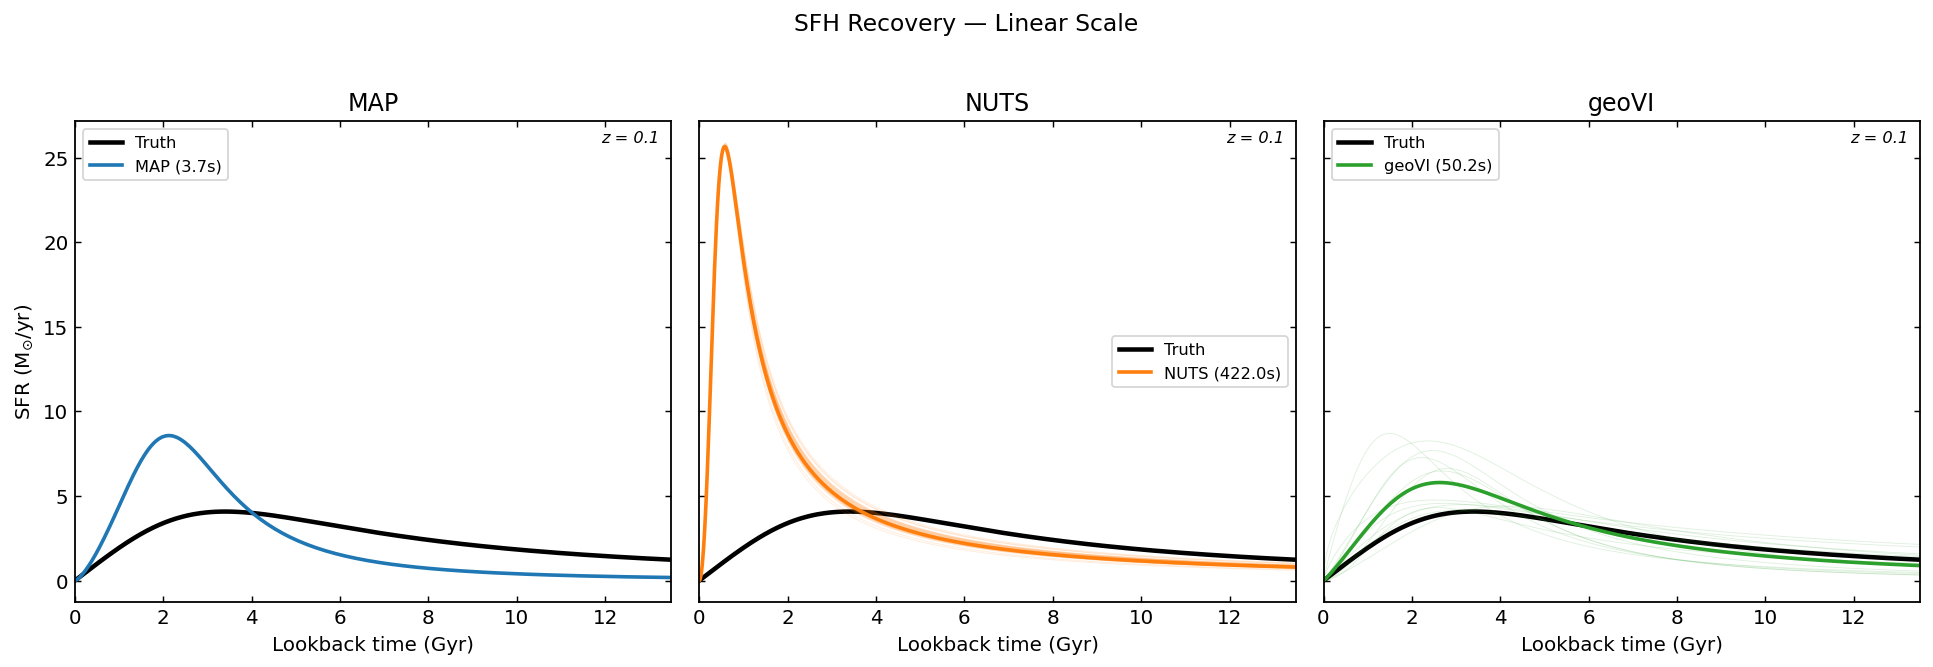

In [6]:
methods = {"MAP": (result_map, "C0")}
if nuts_ok:
    methods["NUTS"] = (result_nuts, "C1")
if geovi_ok:
    methods["geoVI"] = (result_geovi, "C2")

n_methods = len(methods)
fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 5), sharey=True)
if n_methods == 1:
    axes = [axes]

for ax, (name, (res, color)) in zip(axes, methods.items()):
    # Truth
    ax.plot(sfh_true["t_gyr"], sfh_true["sfr_mean"], "k-", lw=2.5, label="Truth")

    # Posterior samples (if available)
    if res.samples is not None:
        n_draw = min(30, len(next(iter(res.samples.values()))))
        for i in range(n_draw):
            sample_i = {k: res.samples[k][i] for k in res.samples}
            sfh_i = model.predict_sfh(sample_i)
            ax.plot(sfh_i["t_gyr"], sfh_i["sfr_mean"], color=color, alpha=0.15, lw=0.5)

    # Best fit / posterior mean
    sfh_fit = model.predict_sfh(res.params)
    ax.plot(sfh_fit["t_gyr"], sfh_fit["sfr_mean"], color=color, lw=2,
            label=f"{name} ({res.wall_time_s:.1f}s)")

    ax.set_xlabel("Lookback time (Gyr)")
    ax.set_xlim(0, 13.5)
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.text(0.98, 0.98, f"z = {true_params['redshift']}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, style="italic")

axes[0].set_ylabel(r"SFR (M$_{\odot}$/yr)")
plt.suptitle("SFH Recovery — Linear Scale", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Parameter Posteriors (Physical Units)

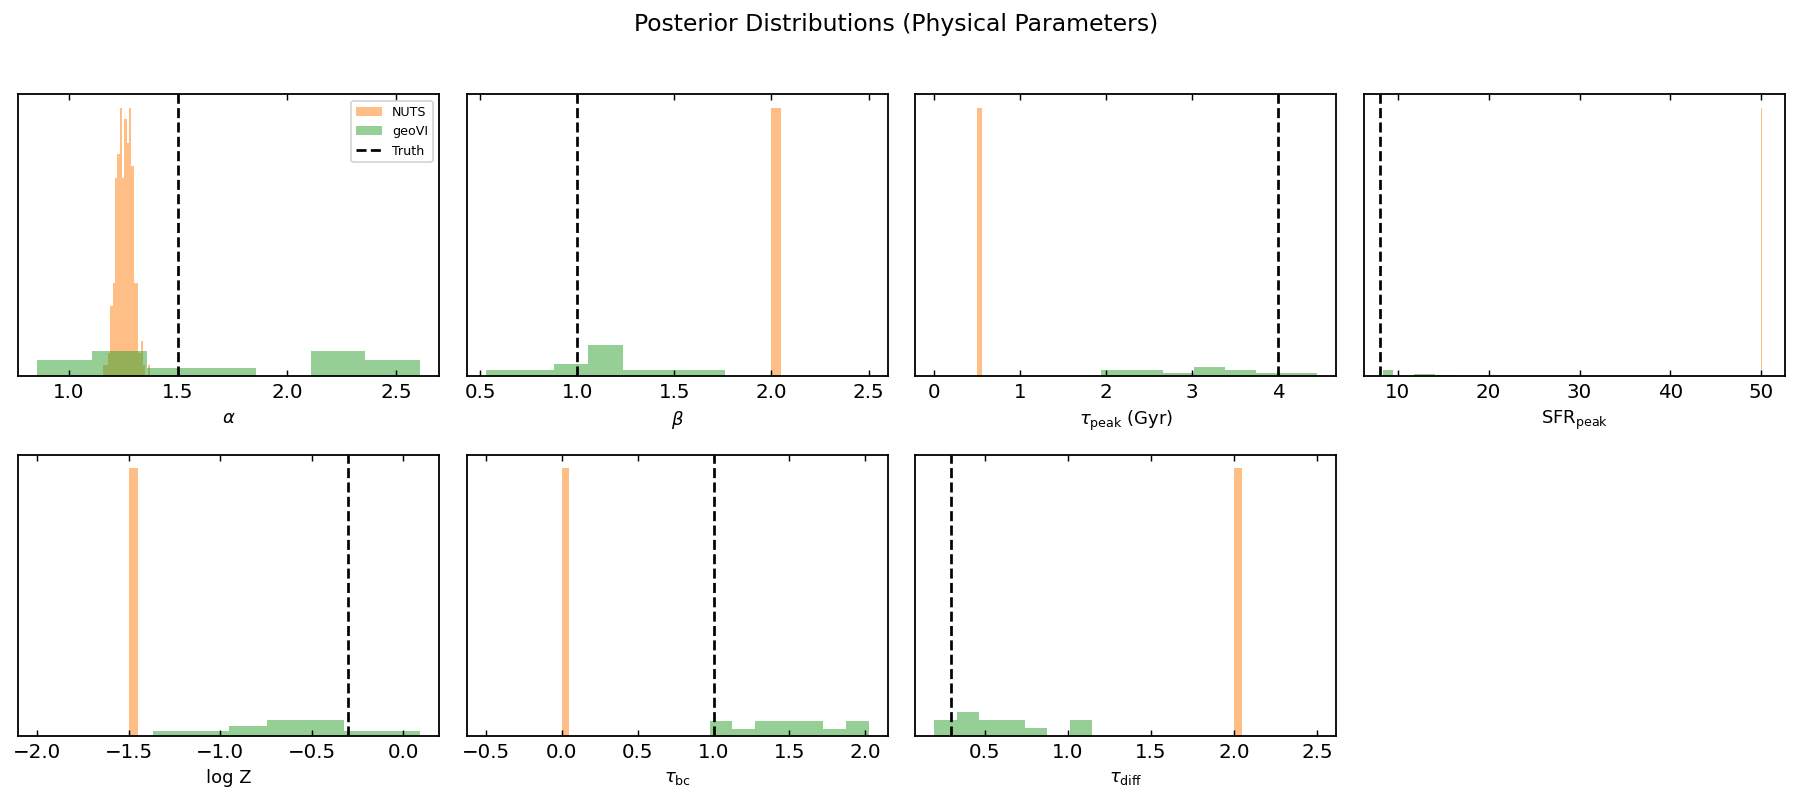

In [7]:
# Show posteriors for methods that have samples
sampling_results = {}
if nuts_ok:
    sampling_results["NUTS"] = (result_nuts, "C1")
if geovi_ok:
    sampling_results["geoVI"] = (result_geovi, "C2")

if sampling_results:
    phys_params = [
        ("sfh_alpha",         r"$\alpha$",                 1.5),
        ("sfh_beta",          r"$\beta$",                  1.0),
        ("sfh_tau_peak_gyr",  r"$\tau_{\rm peak}$ (Gyr)", 4.0),
        ("sfh_peak_sfr",      r"SFR$_{\rm peak}$",        8.0),
        ("met_logzsol",       r"log Z",                    -0.3),
        ("dust_tau_bc",       r"$\tau_{\rm bc}$",         1.0),
        ("dust_tau_diff",     r"$\tau_{\rm diff}$",       0.3),
    ]

    n_params = len(phys_params)
    fig, axes_p = plt.subplots(2, 4, figsize=(14, 6))
    axes_flat = axes_p.ravel()

    for idx, (key, label, true_val) in enumerate(phys_params):
        ax = axes_flat[idx]
        for mname, (res, color) in sampling_results.items():
            if key in res.samples:
                vals = np.array(res.samples[key])
                ax.hist(vals, bins=min(20, len(vals)//2 + 1), color=color,
                        alpha=0.5, density=True, label=mname)
        ax.axvline(true_val, color="k", ls="--", lw=1.5, label="Truth")
        ax.set_xlabel(label, fontsize=10)
        ax.set_yticks([])
        if idx == 0:
            ax.legend(fontsize=7)

    # Hide extra subplot
    axes_flat[-1].set_visible(False)

    fig.suptitle("Posterior Distributions (Physical Parameters)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No sampling methods available — install blackjax or nifty8[re]")

---
## 6. Parameter Recovery Table

In [8]:
print(f"{'Parameter':<22s} {'True':>8s}", end="")
for name in methods:
    print(f"  {name:>12s}", end="")
print()
print("-" * (22 + 10 + 14 * len(methods)))

for key in ["sfh_alpha", "sfh_beta", "sfh_tau_peak_gyr", "sfh_peak_sfr",
            "met_logzsol", "dust_tau_bc", "dust_tau_diff"]:
    true_v = true_params[key]
    print(f"{key:<22s} {true_v:>8.3g}", end="")
    for name, (res, _) in methods.items():
        s = res.summary()
        if key in s:
            if "median" in s[key]:
                print(f"  {s[key]['median']:>12.3g}", end="")
            else:
                print(f"  {s[key]['value']:>12.3g}", end="")
    print()

print()
print("Wall times:")
for name, (res, _) in methods.items():
    print(f"  {name}: {res.wall_time_s:.1f}s")

Parameter                  True           MAP          NUTS         geoVI
--------------------------------------------------------------------------
sfh_alpha                   1.5          2.66          1.26          1.69
sfh_beta                      1          1.41             2           1.1
sfh_tau_peak_gyr              4          2.49           0.5          3.12
sfh_peak_sfr                  8          16.3            50          10.7
met_logzsol                -0.3        -0.664          -1.5        -0.605
dust_tau_bc                   1        0.0825             0           1.5
dust_tau_diff               0.3         0.657             2         0.532

Wall times:
  MAP: 3.7s
  NUTS: 422.0s
  geoVI: 50.2s


---
## 7. Derived Quantities

In [9]:
d_true = model.predict_derived(true_params)

print(f"{'Quantity':<18s} {'True':>12s}", end="")
for name in methods:
    print(f"  {name:>12s}", end="")
print()
print("-" * (18 + 14 + 14 * len(methods)))

for key in ["stellar_mass", "sfr_100myr", "ssfr"]:
    print(f"{key:<18s} {float(d_true[key]):>12.3e}", end="")
    for name, (res, _) in methods.items():
        d = model.predict_derived(res.params)
        print(f"  {float(d[key]):>12.3e}", end="")
    print()

Quantity                   True           MAP          NUTS         geoVI
--------------------------------------------------------------------------
stellar_mass          3.361e+10     3.127e+10     5.654e+10     3.729e+10
sfr_100myr            4.322e-02     2.727e-02     2.203e-01     4.984e-02
ssfr                  1.286e-12     8.721e-13     3.896e-12     1.337e-12


---
## Key Takeaways

1. **MAP** is fastest (seconds) — good for catalogs, no uncertainties
2. **NUTS** gives exact posteriors (minutes) — 10-100x faster than dynesty/MultiNest
3. **geoVI** gives approximate posteriors (seconds) — best speed/accuracy trade-off
4. All three use the **same loss function** and benefit from end-to-end JAX gradients
5. **Photometry alone** constrains the broad SED shape but not individual SFH parameters — spectroscopy helps break degeneracies